# Industrial Ruin Simulator — Shock‑Extended Template

**Purpose**  
Quantify downside cash risk for industrial technology assets under:
- Stochastic operational drift
- Discrete operational shocks
- Discrete customer loss events

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Economic Baseline Assumptions

In [ ]:
MONTHS = 60
N_SIMS = 10_000
INITIAL_CASH = 50_000_000
MONTHLY_FIXED_COST = 6_000_000
MAX_MONTHLY_REVENUE = 25_000_000
GROSS_MARGIN_FULL_YIELD = 0.35

## 3. Baseline Yield Dynamics

In [3]:
INITIAL_YIELD = 0.92
YIELD_DRIFT = -0.002
YIELD_VOL = 0.03

## 4. Operational Shock Assumptions

In [ ]:
ANNUAL_OP_SHOCK_RATE = 0.6
MONTHLY_OP_SHOCK_PROB = ANNUAL_OP_SHOCK_RATE / 12
OP_SHOCK_YIELD_DROP = 0.25
OP_RECOVERY_MONTHS = 6

## 5. Customer Loss Shock Assumptions

In [ ]:
ANNUAL_CUSTOMER_LOSS_RATE = 0.25
MONTHLY_CUSTOMER_LOSS_PROB = ANNUAL_CUSTOMER_LOSS_RATE / 12
CUSTOMER_REVENUE_LOSS = 0.35   # Share of revenue lost
CUSTOMER_RECOVERY_MONTHS = 9

## 6. Single‑Path Simulation Engine

In [ ]:
def simulate_path():
    cash = INITIAL_CASH
    yld = INITIAL_YIELD
    op_shock_active = False
    op_residual_shock = 0.0
    customer_loss_active = False
    customer_loss_remaining = 0
    customer_revenue_factor = 1.0

    for t in range(MONTHS):
        
        # Operational shock arrival
        if (not op_shock_active) and (np.random.rand() < MONTHLY_OP_SHOCK_PROB):
            op_shock_active = True
            op_residual_shock = OP_SHOCK_YIELD_DROP

        # Customer loss arrival
        if (not customer_loss_active) and (np.random.rand() < MONTHLY_CUSTOMER_LOSS_PROB):
            customer_loss_active = True
            customer_loss_remaining = CUSTOMER_RECOVERY_MONTHS
            customer_revenue_factor = 1 - CUSTOMER_REVENUE_LOSS

        # Operational shock mechanics
        if op_shock_active:
            yld *= (1 - op_residual_shock)
            op_residual_shock *= (1 - 1 / OP_RECOVERY_MONTHS)
            if op_residual_shock < 0.01:
                op_shock_active = False

        # Customer recovery mechanics
        if customer_loss_active:
            customer_loss_remaining -= 1
            if customer_loss_remaining <= 0:
                customer_loss_active = False
                customer_revenue_factor = 1.0

        # Baseline yield drift
        yld *= np.exp(np.random.normal(YIELD_DRIFT, YIELD_VOL))
        yld = np.clip(yld, 0.0, 1.0)

        # Economics
        revenue = MAX_MONTHLY_REVENUE * yld * customer_revenue_factor
        gross_profit = revenue * GROSS_MARGIN_FULL_YIELD
        cash += gross_profit - MONTHLY_FIXED_COST

        if cash <= 0:
            return 1, t + 1

    return 0, MONTHS

## 7. Monte Carlo Simulation

In [7]:
ruin = []
time_to_ruin = []

for _ in range(N_SIMS):
    r, t = simulate_path()
    ruin.append(r)
    time_to_ruin.append(t)

ruin = np.array(ruin)
time_to_ruin = np.array(time_to_ruin)

## 8. Core Risk Outputs

In [8]:
prob_ruin = ruin.mean()
median_ttr = np.median(time_to_ruin[ruin == 1])

prob_ruin, median_ttr

(0.8471, 29.0)

## 9. Visualization

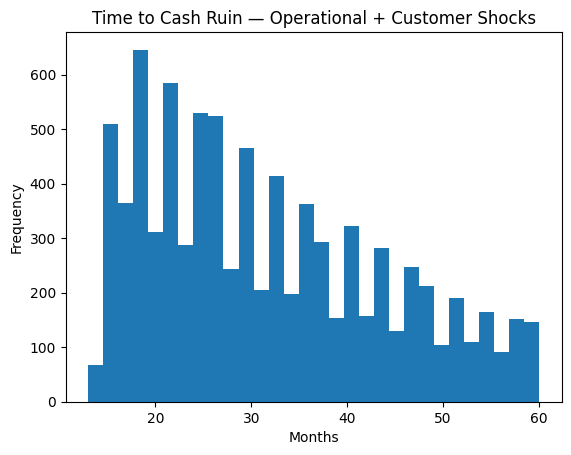

In [9]:
plt.hist(time_to_ruin[ruin == 1], bins=30)
plt.title("Time to Cash Ruin — Operational + Customer Shocks")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.show()

## 10. Deal Interpretation

Combining **operational instability** with **customer concentration risk** materially accelerates cash failure.
